# Ayudantia 4 - Cinetica de Reacciones Homogeneas
**IIQ2113 - Diseno de Reactores** | Profesor Elodie Blanco | 2026-1

---

## Objetivos
En esta ayudantia se comparan dos enfoques para estimar los parametros cineticos
$(k_1, \alpha)$ de una reaccion homogenea $A \xrightarrow{k_1} B$ a partir de datos
de concentracion en el tiempo:

1. **Metodo numerico**: diferencias finitas + regresion lineal en espacio logaritmico.
2. **Metodo de optimizacion**: minimos cuadrados sobre la solucion numerica de la EDO.

Ambos metodos se evaluan en dos escenarios: datos ideales (sin ruido) y datos experimentales
realistas (con ruido gaussiano).

---

## Librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

# Semilla global para reproducibilidad
SEED = 99
np.random.seed(SEED)

# Tamanos de fuente globales para las figuras
FS = dict(label=16, title=18, tick=13, legend=13)

---
# Seccion 1 - Datos sin ruido

La cinetica verdadera es:
$$\frac{dC_A}{dt} = -k_1\,C_A^{\alpha}, \qquad k_1^\star = 0.1\,\text{h}^{-1},\ \alpha^\star = 1.2$$

Generamos 20 puntos de concentracion integrando numericamente las EDOs, sin agregar ruido.
El objetivo es verificar que ambos metodos recuperan los parametros correctos.

In [ ]:
# -- Modelo cinetico (EDO) -------------------------------------------------
def modelo_cinetico(t, y, params):
    """
    Sistema de EDOs para la reaccion A -> B con cinetica de potencias.
    Parametros
    ----------
    t : float -- tiempo actual (requerido por solve_ivp)
    y : list -- estado [Ca, Cb]
    params : tuple -- (k, alpha)

    Retorna
    -------
    [dCa_dt, dCb_dt]
    """
    k, alpha = params
    Ca, Cb = y
    dCa_dt = -k * Ca**alpha
    dCb_dt = k * Ca**alpha
    return [dCa_dt, dCb_dt]

# Parametros verdaderos

k_star = 0.1 # constante de velocidad real
alpha_star = 1.2 # orden de reaccion real

# -- Condiciones iniciales y horizonte temporal

Ca0 = 1.0 # [M]
Cb0 = 0.0 # [M]
y0 = [Ca0, Cb0]
t_span = [0, 50] # [h]
t_eval = np.linspace(t_span[0], t_span[1], 20) # 20 puntos de evaluacion

# Integracion numerica -- Resolvermos la edo

sol_clean = solve_ivp(
    modelo_cinetico, t_span, y0,
    args=((k_star, alpha_star),),
    t_eval=t_eval,
)

# -- DataFrame de trabajo --------------------------------------------------
datos = pd.DataFrame({
    'time': sol_clean.t,
    'Ca': sol_clean.y[0],
    'Cb': sol_clean.y[1],
})
# el siguiente comando imprime el dataframe en formato LaTeX con 4 decimales y un caption personalizado
# permite copiar y pegar directamente en un documento LaTeX (overleaf)
print(datos.to_latex(float_format='%.4f', caption='Datos de la reacción homogénea \\ce{A ->[k_1] B} en un reactor batch a volumen constante.'))

\begin{table}
\caption{Datos de la reacción homogénea \ce{A ->[k_1] B} en un reactor batch a volumen constante.}
\begin{tabular}{lrrr}
\toprule
 & time & Ca & Cb \\
\midrule
0 & 0.0000 & 1.0000 & 0.0000 \\
1 & 2.6316 & 0.7737 & 0.2263 \\
2 & 5.2632 & 0.6063 & 0.3937 \\
3 & 7.8947 & 0.4805 & 0.5195 \\
4 & 10.5263 & 0.3847 & 0.6153 \\
5 & 13.1579 & 0.3111 & 0.6889 \\
6 & 15.7895 & 0.2537 & 0.7463 \\
7 & 18.4211 & 0.2085 & 0.7915 \\
8 & 21.0526 & 0.1727 & 0.8273 \\
9 & 23.6842 & 0.1441 & 0.8559 \\
10 & 26.3158 & 0.1209 & 0.8791 \\
11 & 28.9474 & 0.1020 & 0.8980 \\
12 & 31.5789 & 0.0866 & 0.9134 \\
13 & 34.2105 & 0.0740 & 0.9260 \\
14 & 36.8421 & 0.0635 & 0.9365 \\
15 & 39.4737 & 0.0546 & 0.9454 \\
16 & 42.1053 & 0.0473 & 0.9527 \\
17 & 44.7368 & 0.0411 & 0.9589 \\
18 & 47.3684 & 0.0359 & 0.9641 \\
19 & 50.0000 & 0.0314 & 0.9686 \\
\bottomrule
\end{tabular}
\end{table}



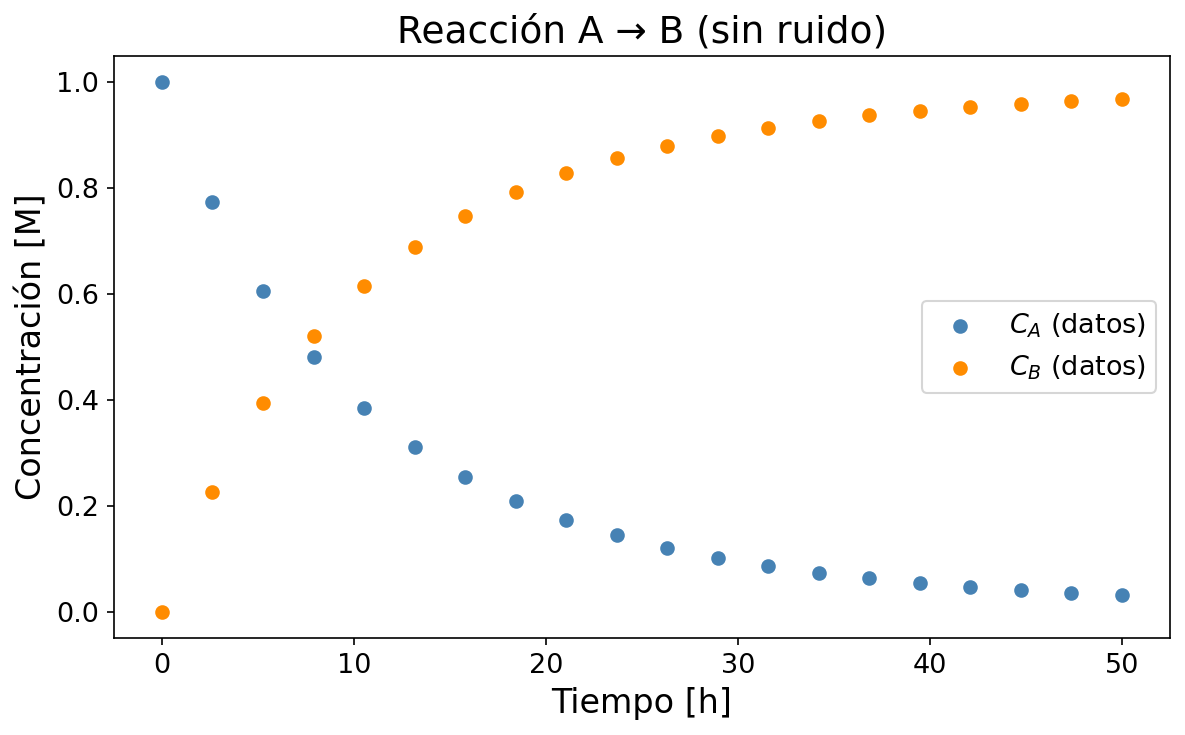

In [3]:
# -- Visualizacion de los datos limpios ------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
ax.scatter(datos['time'], datos['Ca'], label='$C_A$ (datos)', color='steelblue', zorder=3)
ax.scatter(datos['time'], datos['Cb'], label='$C_B$ (datos)', color='darkorange', zorder=3)
ax.set_xlabel('Tiempo [h]', fontsize=FS['label'])
ax.set_ylabel('Concentracion [M]', fontsize=FS['label'])
ax.set_title('Reaccion A -> B (sin ruido)', fontsize=FS['title'])
ax.tick_params(labelsize=FS['tick'])
ax.legend(fontsize=FS['legend'])
plt.tight_layout()
plt.savefig('reaccion_homogenea1_concentracion.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## 1.1 Metodo numerico - Diferencias finitas + Regresion lineal

### Idea
Tomando logaritmo de la EDO $-dC_A/dt = k_1 C_A^{\alpha}$:
$$\ln\!\left(-\frac{dC_A}{dt}\right) = \underbrace{\ln(k_1)}_{b} + \underbrace{\alpha}_{m}\,\ln(C_A)$$

Esto es una recta $y = b + mx$ con $y = \ln(-dC_A/dt)$ y $x = \ln(C_A)$.  
Para obtener $dC_A/dt$ usamos **diferencias finitas centradas de 2o orden**:

| Punto | Formula |
|-------|--------|
| Inicial $t_0$ | $(-3C_{A,0} + 4C_{A,1} - C_{A,2})\,/\,(2\Delta t)$ |
| Intermedios $t_i$ | $(C_{A,i+1} - C_{A,i-1})\,/\,(2\Delta t)$ |
| Final $t_N$ | $(3C_{A,N} - 4C_{A,N-1} + C_{A,N-2})\,/\,(2\Delta t)$ |

> **Convencion de `np.polyfit`**: para `deg=1`, retorna `[slope, intercept]`  
> (orden descendente de potencia). Por tanto `params[0]` es la pendiente ($\alpha$)  
> y `params[1]` es el intercepto ($\ln k_1$).

In [ ]:
def diferencias_finitas(y, t):
    """
    Estima dy/dt con diferencias finitas centradas de 2o orden.

    Parametros
    ----------
    y : np.ndarray -- valores de la funcion (e.g., concentraciones)
    t : np.ndarray -- tiempos correspondientes (espaciado uniforme)

    Retorna
    -------
    dy_dt : np.ndarray
    """
    dy_dt = np.zeros_like(y, dtype=float)
    dt = t[1] - t[0] # paso temporal

    dy_dt[0] = (-3*y[0] + 4*y[1] - y[2]) / (2*dt) # punto inicial
    dy_dt[1:-1] = (y[2:] - y[:-2]) / (2*dt) # puntos intermedios
    dy_dt[-1] = (3*y[-1] - 4*y[-2] + y[-3]) / (2*dt) # punto final

    return dy_dt

In [ ]:
# -- Calcular derivadas numericas ------------------------------------------
datos['dCa_dt'] = diferencias_finitas(datos['Ca'].values, datos['time'].values)
datos['dCb_dt'] = diferencias_finitas(datos['Cb'].values, datos['time'].values)

Diferencias finitas (sin ruido)
 k_1 estimado = 0.1009 | real = 0.1
 alpha estimado = 1.2019 | real = 1.2


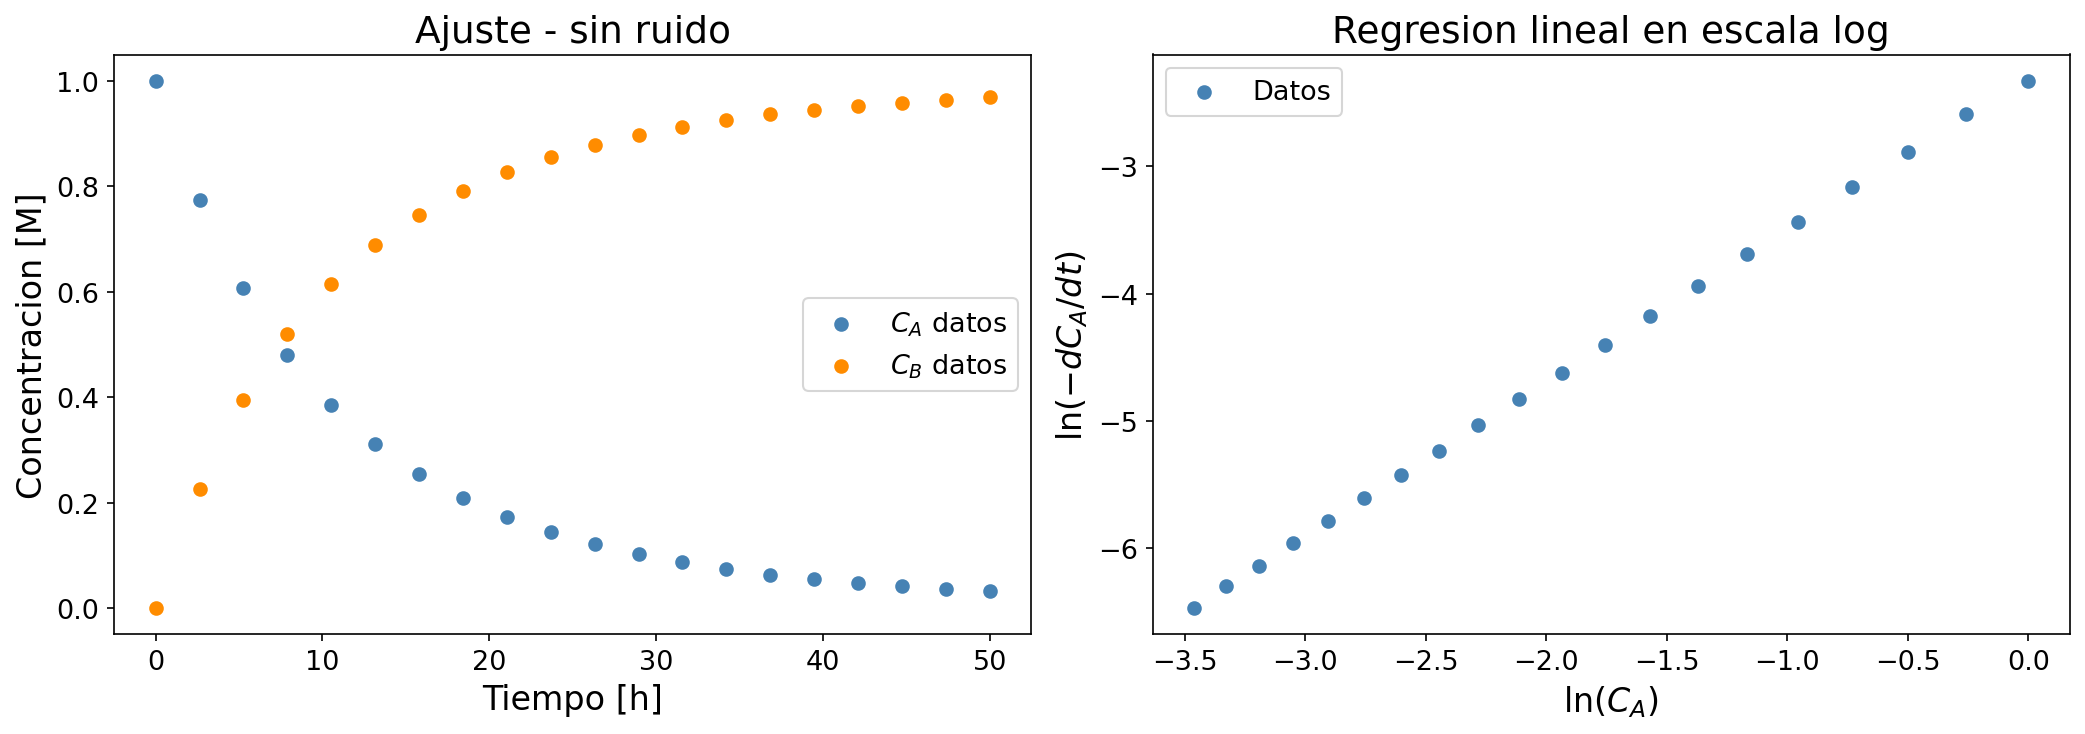

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# --- Concentracion vs tiempo ---
ax = axes[0]
ax.scatter(datos['time'], datos['Ca'], label='$C_A$ datos', color='steelblue', zorder=3)
ax.scatter(datos['time'], datos['Cb'], label='$C_B$ datos', color='darkorange', zorder=3)
ax.set_xlabel('Tiempo [h]', fontsize=FS['label'])
ax.set_ylabel('Concentracion [M]', fontsize=FS['label'])
ax.set_title('Ajuste - sin ruido', fontsize=FS['title'])
ax.tick_params(labelsize=FS['tick'])
ax.legend(fontsize=FS['legend'])

# --- log(Ca) vs log(-dCa/dt) ---
ax = axes[1]
x_plot = np.linspace(np.log(datos['Ca']).min(), np.log(datos['Ca']).max(), 100)
ax.scatter(np.log(datos['Ca']), np.log(-datos['dCa_dt']), color='steelblue', zorder=3,
           label='Datos')
ax.set_xlabel(r'$\ln(C_A)$', fontsize=FS['label'])
ax.set_ylabel(r'$\ln(-dC_A/dt)$', fontsize=FS['label'])
ax.set_title(r'Regresion lineal en escala log', fontsize=FS['title'])
ax.tick_params(labelsize=FS['tick'])
ax.legend(fontsize=FS['legend'])

plt.tight_layout()
plt.savefig('reaccion_homogenea1_cavsdca.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
#
print(datos.to_latex(float_format='%.4f', index=False,caption='Datos de la reacción homogénea \\ce{A->[k_1] B} con derivadas estimadas mediantediferencias finitas.'))

\begin{table}
\caption{Datos de la reacción homogénea \ce{A->[k_1] B} con derivadas estimadas mediantediferencias finitas.}
\begin{tabular}{rrrrr}
\toprule
time & Ca & Cb & dCa_dt & dCb_dt \\
\midrule
0.0000 & 1.0000 & 0.0000 & -0.0972 & 0.0972 \\
2.6316 & 0.7737 & 0.2263 & -0.0748 & 0.0748 \\
5.2632 & 0.6063 & 0.3937 & -0.0557 & 0.0557 \\
7.8947 & 0.4805 & 0.5195 & -0.0421 & 0.0421 \\
10.5263 & 0.3847 & 0.6153 & -0.0322 & 0.0322 \\
13.1579 & 0.3111 & 0.6889 & -0.0249 & 0.0249 \\
15.7895 & 0.2537 & 0.7463 & -0.0195 & 0.0195 \\
18.4211 & 0.2085 & 0.7915 & -0.0154 & 0.0154 \\
21.0526 & 0.1727 & 0.8273 & -0.0122 & 0.0122 \\
23.6842 & 0.1441 & 0.8559 & -0.0098 & 0.0098 \\
26.3158 & 0.1209 & 0.8791 & -0.0080 & 0.0080 \\
28.9474 & 0.1020 & 0.8980 & -0.0065 & 0.0065 \\
31.5789 & 0.0866 & 0.9134 & -0.0053 & 0.0053 \\
34.2105 & 0.0740 & 0.9260 & -0.0044 & 0.0044 \\
36.8421 & 0.0635 & 0.9365 & -0.0037 & 0.0037 \\
39.4737 & 0.0546 & 0.9454 & -0.0031 & 0.0031 \\
42.1053 & 0.0473 & 0.9527 & -0.0026

In [ ]:

# -- Regresion lineal -------------------------------
# np.polyfit(x, y, 1) retorna [slope, intercept]
params_fd = np.polyfit(np.log(datos['Ca']), np.log(-datos['dCa_dt']), 1)
alpha_fd = params_fd[0] # pendiente -> orden de reaccion
k_fd = np.exp(params_fd[1]) # intercepto -> ln(k), se revierte con exp

print(f"Diferencias finitas (sin ruido)")
print(f" k_1 estimado = {k_fd:.4f} | real = {k_star}")
print(f" alpha estimado = {alpha_fd:.4f} | real = {alpha_star}")

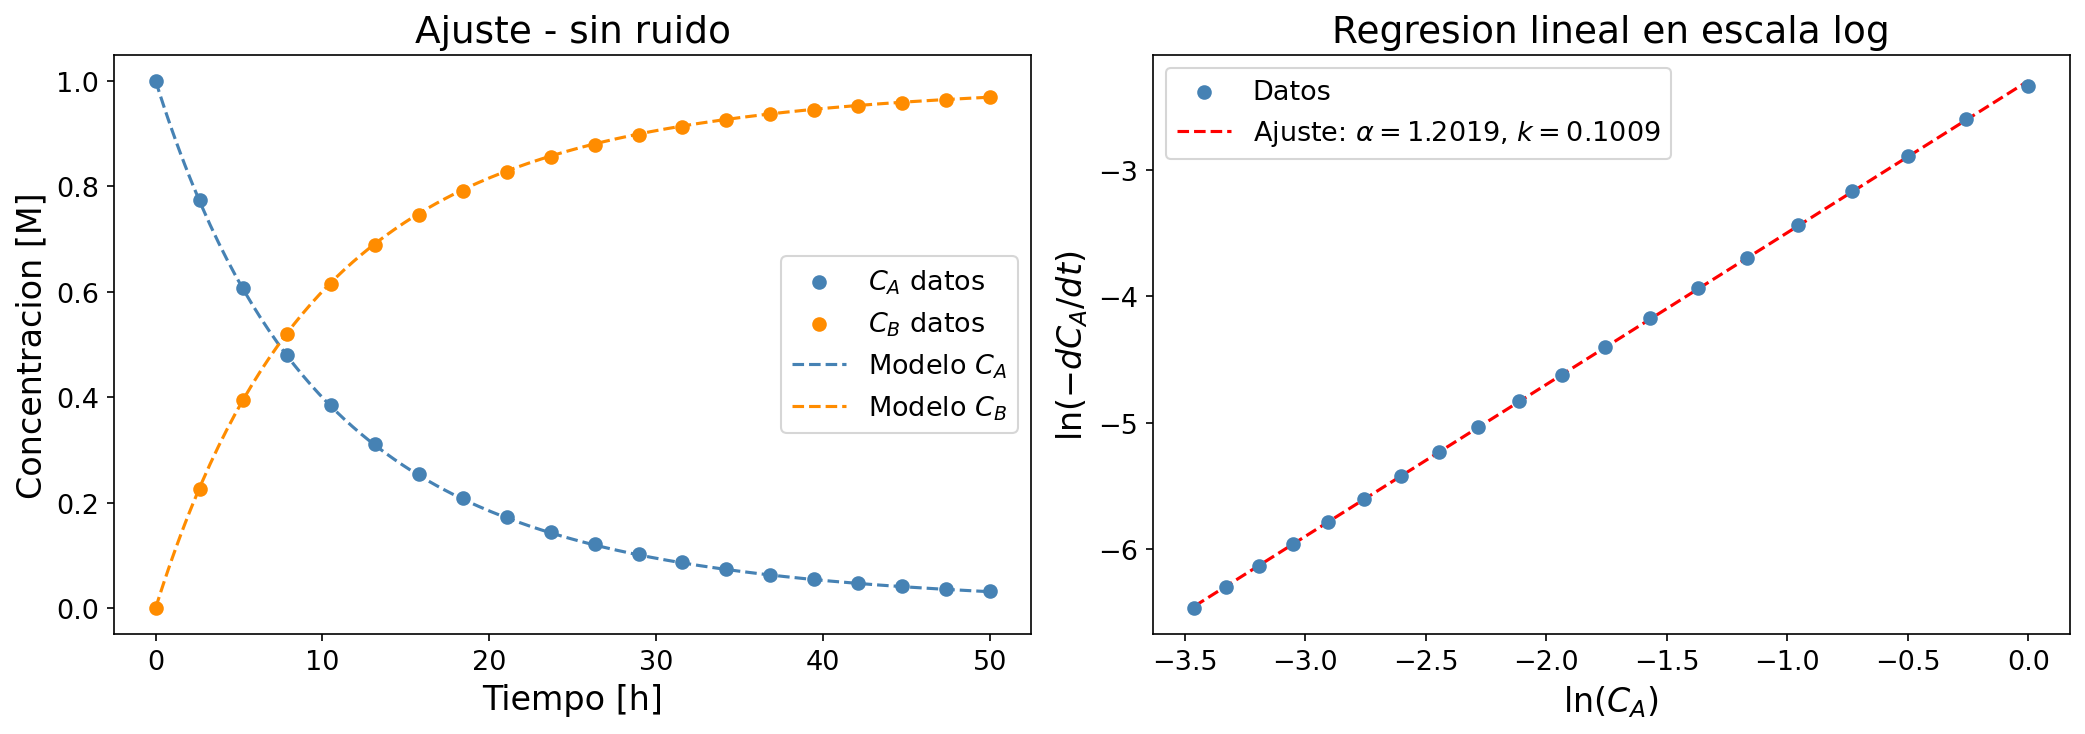

In [28]:
# -- Modelo ajustado con parametros de diferencias finitas ----------------
sol_fd = solve_ivp(
    modelo_cinetico, t_span, y0,
    args=((k_fd, alpha_fd),),
    t_eval=np.linspace(*t_span, 200),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# --- Concentracion vs tiempo ---
ax = axes[0]
ax.scatter(datos['time'], datos['Ca'], label='$C_A$ datos', color='steelblue', zorder=3)
ax.scatter(datos['time'], datos['Cb'], label='$C_B$ datos', color='darkorange', zorder=3)
ax.plot(sol_fd.t, sol_fd.y[0], '--', label='Modelo $C_A$', color='steelblue')
ax.plot(sol_fd.t, sol_fd.y[1], '--', label='Modelo $C_B$', color='darkorange')
ax.set_xlabel('Tiempo [h]', fontsize=FS['label'])
ax.set_ylabel('Concentracion [M]', fontsize=FS['label'])
ax.set_title('Ajuste - sin ruido', fontsize=FS['title'])
ax.tick_params(labelsize=FS['tick'])
ax.legend(fontsize=FS['legend'])

# --- log(Ca) vs log(-dCa/dt) ---
ax = axes[1]
x_plot = np.linspace(np.log(datos['Ca']).min(), np.log(datos['Ca']).max(), 100)
ax.scatter(np.log(datos['Ca']), np.log(-datos['dCa_dt']), color='steelblue', zorder=3,
           label='Datos')
ax.plot(x_plot, params_fd[0]*x_plot + params_fd[1], 'r--',
        label=f'Ajuste: $\\alpha={alpha_fd:.4f}$, $k={k_fd:.4f}$')
ax.set_xlabel(r'$\ln(C_A)$', fontsize=FS['label'])
ax.set_ylabel(r'$\ln(-dC_A/dt)$', fontsize=FS['label'])
ax.set_title(r'Regresion lineal en escala log', fontsize=FS['title'])
ax.tick_params(labelsize=FS['tick'])
ax.legend(fontsize=FS['legend'])

plt.tight_layout()
plt.savefig('reaccion_homogenea1_sol_numer.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## 1.2 Metodo de optimizacion - Minimos cuadrados sobre la EDO

### Idea
En lugar de linealizar, buscamos los parametros $\theta = [k_1, \alpha]$ que minimizan
la suma de cuadrados entre la **solucion numerica de la EDO** y los datos:

$$\hat{\theta} = \arg\min_{\theta}\;\sum_{j} \bigl(\hat{C}_A(t_j|\theta) - C_A^\star(t_j)\bigr)^2$$

Usamos `scipy.optimize.minimize` con el metodo `L-BFGS-B` (soporta restricciones de caja).

> **Ventaja clave**: no se calculan derivadas numericas de los datos, lo que hace al metodo
> considerablemente mas robusto al ruido.

In [ ]:
def funcion_objetivo(params, t_data, Ca_exp, y0):
    """
    Suma de cuadrados del error entre la EDO integrada y los datos de Ca.

    Parametros
    ----------
    params : array-like -- [k, alpha] a optimizar
    t_data : np.ndarray -- tiempos experimentales
    Ca_exp : np.ndarray -- concentraciones experimentales de A
    y0 : list -- condiciones iniciales [Ca0, Cb0]

    Retorna
    -------
    SSE : float
    """
    sol = solve_ivp(
        modelo_cinetico, # modelo EDO 
        (t_data[0], t_data[-1]), # tiempo de integracion de los datos
        y0, # condiciones iniciales
        args=(params,), # parametros a optimizar
        t_eval=t_data, # tiempo de evaluación de los datos
    )
    Ca_model = sol.y[0] # estimación del modelo cinético
    return np.sum((Ca_model - Ca_exp)**2)

In [41]:
# -- Optimizacion ----------------------------------------------------------
initial_guess = [0.1, 1.0] # punto de partida o guess inicial para [k, alpha]
datos_Ca = datos['Ca'].values # datos experimentales de Ca
tiempo_exp = datos['time'].values # tiempos experimentales
# y0 viene de arriba 
resultado = minimize(
    funcion_objetivo, # funcion objetivo a minimizar
    x0 = initial_guess, # punto de partida
    args=(tiempo_exp, datos_Ca, y0),
    bounds=((1e-6, None), (1e-6, None)), # k > 0, alpha > 0
)

k_opt, alpha_opt = resultado.x
print(f"Optimizacion (sin ruido)")
print(f" k_1 estimado = {k_opt:.4f} | real = {k_star}")
print(f" alpha estimado = {alpha_opt:.4f} | real = {alpha_star}")

Optimizacion (sin ruido)
 k_1 estimado = 0.1000 | real = 0.1
 alpha estimado = 1.2000 | real = 1.2


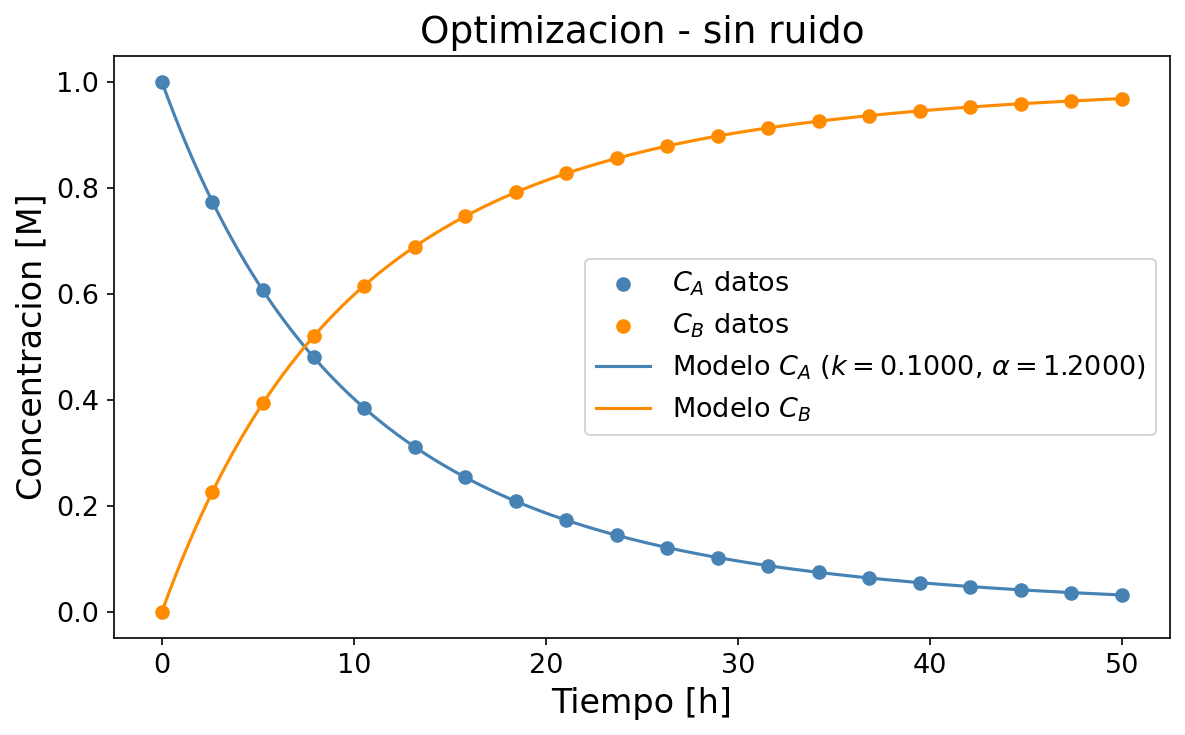

In [42]:
# -- Visualizacion del ajuste optimizado -----------------------------------
t_fine = np.linspace(*t_span, 300)
sol_opt = solve_ivp(modelo_cinetico, t_span, y0,
                      args=((k_opt, alpha_opt),), t_eval=t_fine)

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
ax.scatter(datos['time'], datos['Ca'], label='$C_A$ datos', color='steelblue', zorder=3)
ax.scatter(datos['time'], datos['Cb'], label='$C_B$ datos', color='darkorange', zorder=3)
ax.plot(sol_opt.t, sol_opt.y[0], color='steelblue', label=f'Modelo $C_A$ ($k={k_opt:.4f}$, $\\alpha={alpha_opt:.4f}$)')
ax.plot(sol_opt.t, sol_opt.y[1], color='darkorange', label='Modelo $C_B$')
ax.set_xlabel('Tiempo [h]', fontsize=FS['label'])
ax.set_ylabel('Concentracion [M]', fontsize=FS['label'])
ax.set_title('Optimizacion - sin ruido', fontsize=FS['title'])
ax.tick_params(labelsize=FS['tick'])
ax.legend(fontsize=FS['legend'])
plt.tight_layout()
plt.savefig('reaccion_homogenea1_opt.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
# Seccion 2 - Datos con ruido

En la practica experimental, los datos siempre presentan **ruido de medicion**.
Simulamos esto agregando perturbaciones gaussianas $\varepsilon \sim \mathcal{N}(0,\,0.05^2)$
a las concentraciones ideales.

> **?Por que las diferencias finitas fallan con ruido?**  
> Al derivar numericamente, el ruido se **amplifica** por un factor $\sim \sigma/(\sqrt{2}\Delta t)$.  
> Con pocos puntos (paso $\Delta t$ grande), este factor puede superar a la derivada real,
> destruyendo la informacion cinetica.

In [ ]:
# -- Generacion de datos con ruido -----------------------------------------
np.random.seed(SEED) # garantiza reproducibilidad
SIGMA = 0.05 # desviacion estandar del ruido [M]

# Integracion con los parametros verdaderos (igual que Seccion 1)
t_eval_ruido = np.linspace(*t_span, 10) # solo 10 puntos (menos mediciones)
sol_ideal = solve_ivp(
    modelo_cinetico, t_span, y0,
    args=((k_star, alpha_star),),
    t_eval=t_eval_ruido,
    method='RK45', rtol=1e-8, atol=1e-10
)

# Agregar ruido y recortar para evitar concentraciones negativas
Ca_ruido = np.clip(sol_ideal.y[0] + np.random.normal(0, SIGMA, sol_ideal.y[0].shape), 1e-6, None)
Cb_ruido = np.clip(sol_ideal.y[1] + np.random.normal(0, SIGMA, sol_ideal.y[1].shape), 1e-6, None)

datos_ruido = pd.DataFrame({
    'time': sol_ideal.t,
    'Ca': Ca_ruido,
    'Cb': Cb_ruido,
})
print(datos_ruido.to_string(index=False, float_format='%.3f'))

  time    Ca    Cb
 0.000 0.993 0.000
 5.556 0.693 0.444
11.111 0.381 0.635
16.667 0.304 0.786
22.222 0.151 0.854
27.778 0.106 0.818
33.333 0.116 0.966
38.889 0.098 0.915
44.444 0.036 0.933
50.000 0.000 0.998


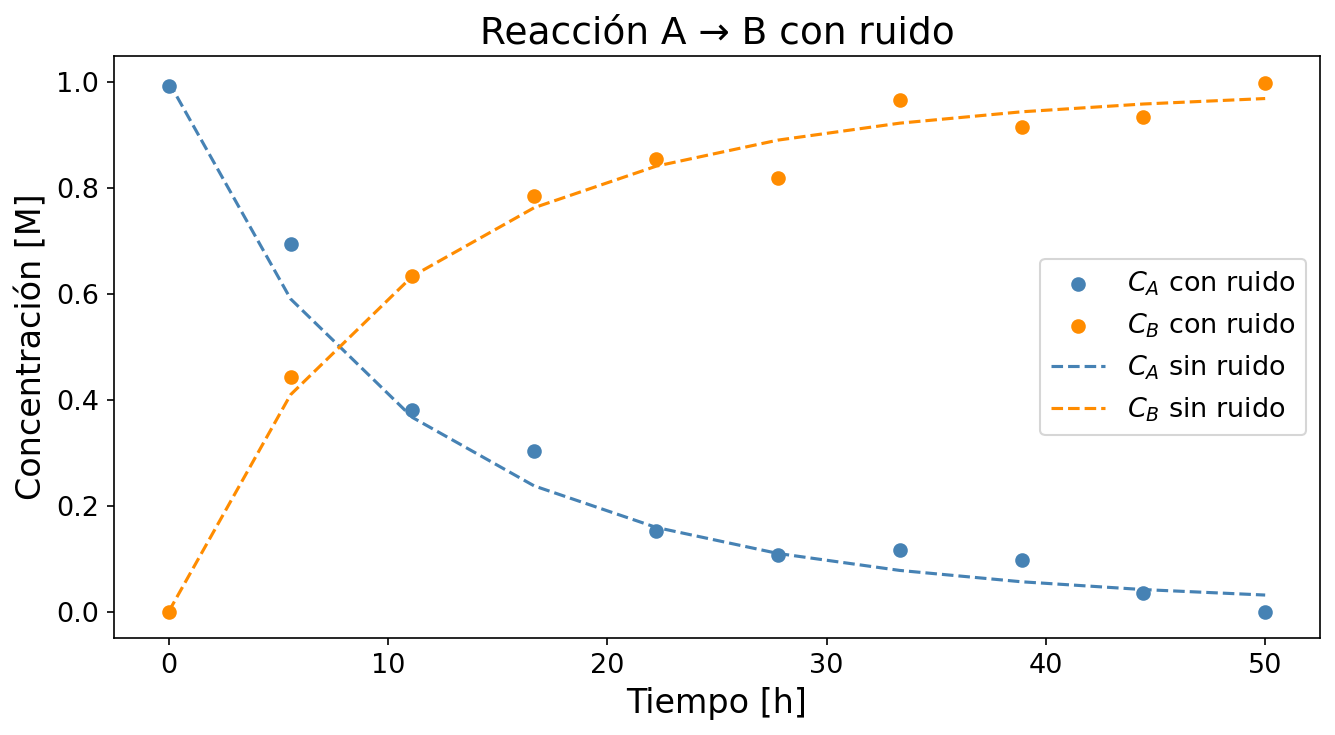

In [11]:
# -- Comparacion ideal vs ruidoso ------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
ax.scatter(datos_ruido['time'], datos_ruido['Ca'],
           label='$C_A$ con ruido', color='steelblue', zorder=3)
ax.scatter(datos_ruido['time'], datos_ruido['Cb'],
           label='$C_B$ con ruido', color='darkorange', zorder=3)
ax.plot(sol_ideal.t, sol_ideal.y[0], '--', color='steelblue', label='$C_A$ sin ruido')
ax.plot(sol_ideal.t, sol_ideal.y[1], '--', color='darkorange', label='$C_B$ sin ruido')
ax.set_xlabel('Tiempo [h]', fontsize=FS['label'])
ax.set_ylabel('Concentracion [M]', fontsize=FS['label'])
ax.set_title('Reaccion A -> B con ruido', fontsize=FS['title'])
ax.tick_params(labelsize=FS['tick'])
ax.legend(fontsize=FS['legend'])
plt.tight_layout()
plt.savefig('reaccion_homogenea1_ruido.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## 2.1 Diferencias finitas con datos ruidosos

In [ ]:
# -- Derivadas numericas de los datos ruidosos -----------------------------
datos_ruido['dCa_dt'] = diferencias_finitas(datos_ruido['Ca'].values, datos_ruido['time'].values)
datos_ruido['dCb_dt'] = diferencias_finitas(datos_ruido['Cb'].values, datos_ruido['time'].values)

# -- Regresion lineal ------------------------------------------------------
params_fd_r = np.polyfit(np.log(datos_ruido['Ca']), np.log(-datos_ruido['dCa_dt']), 1)
alpha_fd_r = params_fd_r[0] # pendiente
k_fd_r = np.exp(params_fd_r[1]) # intercepto -> k

print(f"Diferencias finitas (CON ruido sigma={SIGMA})")
print(f" k_1 estimado = {k_fd_r:.4f} | real = {k_star}")
print(f" alpha estimado = {alpha_fd_r:.4f} | real = {alpha_star}")

Diferencias finitas (CON ruido sigma=0.05)
  k_1   estimado  = 0.0163   |  real = 0.1
  alpha estimado  = 0.1408   |  real = 1.2


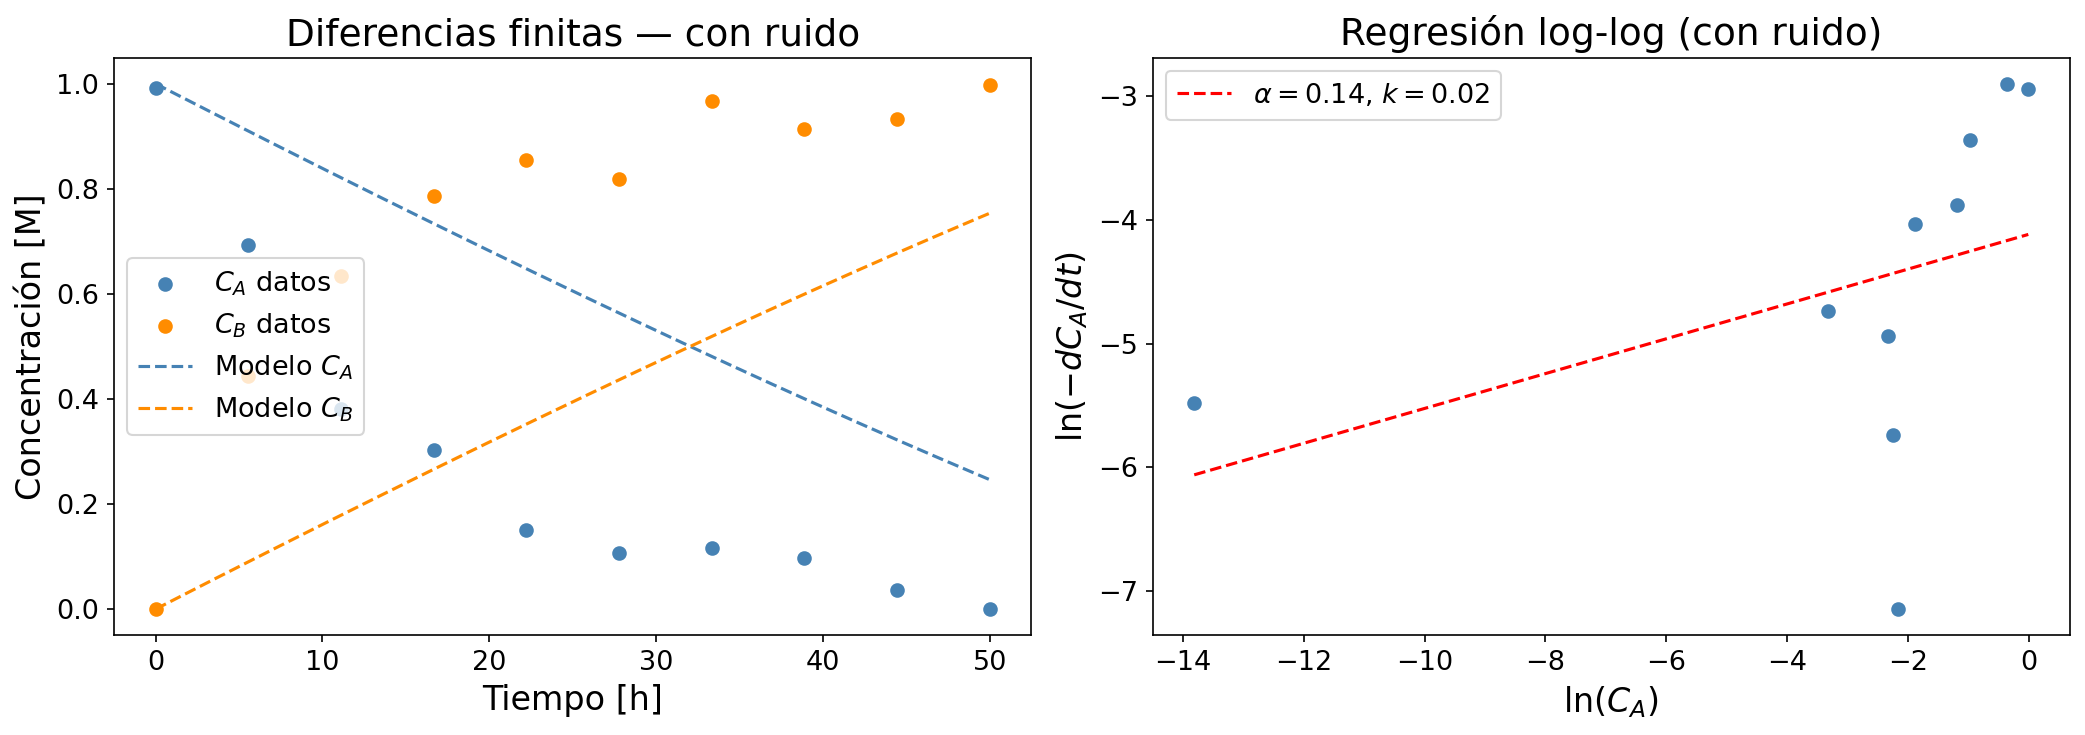

In [13]:
# -- Modelo predicho con parametros degradados por ruido -------------------
sol_fd_r = solve_ivp(
    modelo_cinetico, t_span, y0,
    args=((k_fd_r, alpha_fd_r),),
    t_eval=np.linspace(*t_span, 200),
    method='BDF', # BDF es mas estable para parametros degenerados
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Concentracion vs tiempo
ax = axes[0]
ax.scatter(datos_ruido['time'], datos_ruido['Ca'], label='$C_A$ datos', color='steelblue', zorder=3)
ax.scatter(datos_ruido['time'], datos_ruido['Cb'], label='$C_B$ datos', color='darkorange', zorder=3)
ax.plot(sol_fd_r.t, sol_fd_r.y[0], '--', color='steelblue', label='Modelo $C_A$')
ax.plot(sol_fd_r.t, sol_fd_r.y[1], '--', color='darkorange', label='Modelo $C_B$')
ax.set_xlabel('Tiempo [h]', fontsize=FS['label'])
ax.set_ylabel('Concentracion [M]', fontsize=FS['label'])
ax.set_title('Diferencias finitas - con ruido', fontsize=FS['title'])
ax.tick_params(labelsize=FS['tick'])
ax.legend(fontsize=FS['legend'])

# Regresion lineal log-log
ax = axes[1]
x_r = np.log(datos_ruido['Ca'])
x_plot_r = np.linspace(x_r.min(), x_r.max(), 100)
ax.scatter(x_r, np.log(-datos_ruido['dCa_dt']), color='steelblue', zorder=3)
ax.plot(x_plot_r, params_fd_r[0]*x_plot_r + params_fd_r[1], 'r--',
        label=f'$\\alpha={alpha_fd_r:.2f}$, $k={k_fd_r:.2f}$')
ax.set_xlabel(r'$\ln(C_A)$', fontsize=FS['label'])
ax.set_ylabel(r'$\ln(-dC_A/dt)$', fontsize=FS['label'])
ax.set_title('Regresion log-log (con ruido)', fontsize=FS['title'])
ax.tick_params(labelsize=FS['tick'])
ax.legend(fontsize=FS['legend'])

plt.tight_layout()
plt.savefig('reaccion_homogenea1_ruido_numerico.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## 2.2 Optimizacion con datos ruidosos

In [ ]:
# -- Optimizacion sobre los datos ruidosos ---------------------------------
resultado_r = minimize(
    funcion_objetivo,
    x0=[0.1, 1.0],
    args=(datos_ruido['time'].values, datos_ruido['Ca'].values, y0),
    method='L-BFGS-B',
    bounds=((1e-6, None), (1e-6, None)),
)

k_opt_r, alpha_opt_r = resultado_r.x
print(f"Optimizacion (CON ruido sigma={SIGMA})")
print(f" k_1 estimado = {k_opt_r:.4f} | real = {k_star}")
print(f" alpha estimado = {alpha_opt_r:.4f} | real = {alpha_star}")
print(f" Convergencia: {resultado_r.success} - {resultado_r.message}")

Optimizacion (CON ruido sigma=0.05)
  k_1   estimado  = 0.0785   |  real = 0.1
  alpha estimado  = 1.0417   |  real = 1.2
  Convergencia: True - CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


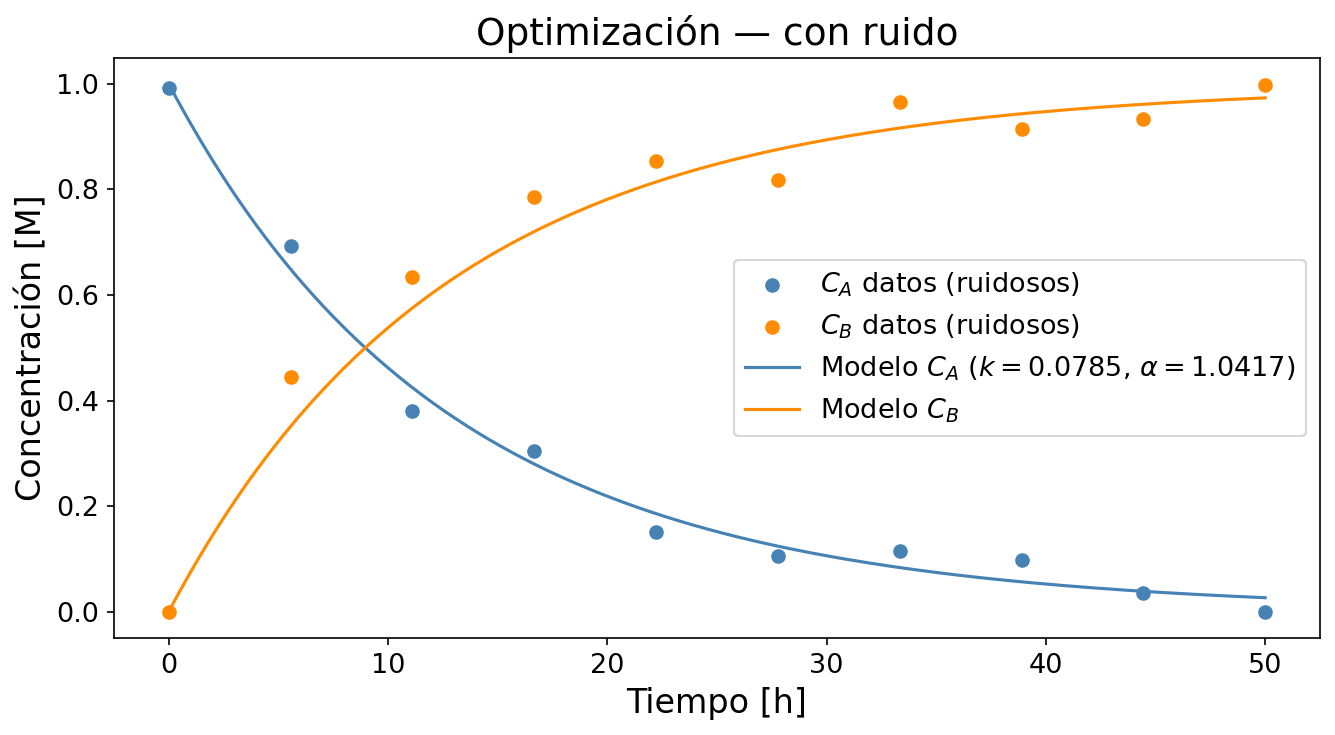

In [15]:
# -- Visualizacion final ---------------------------------------------------
sol_opt_r = solve_ivp(
    modelo_cinetico, t_span, y0,
    args=((k_opt_r, alpha_opt_r),),
    t_eval=np.linspace(*t_span, 300),
)

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
ax.scatter(datos_ruido['time'], datos_ruido['Ca'],
           label='$C_A$ datos (ruidosos)', color='steelblue', zorder=3)
ax.scatter(datos_ruido['time'], datos_ruido['Cb'],
           label='$C_B$ datos (ruidosos)', color='darkorange', zorder=3)
ax.plot(sol_opt_r.t, sol_opt_r.y[0], color='steelblue',
        label=f'Modelo $C_A$ ($k={k_opt_r:.4f}$, $\\alpha={alpha_opt_r:.4f}$)')
ax.plot(sol_opt_r.t, sol_opt_r.y[1], color='darkorange', label='Modelo $C_B$')
ax.set_xlabel('Tiempo [h]', fontsize=FS['label'])
ax.set_ylabel('Concentracion [M]', fontsize=FS['label'])
ax.set_title('Optimizacion - con ruido', fontsize=FS['title'])
ax.tick_params(labelsize=FS['tick'])
ax.legend(fontsize=FS['legend'])
plt.tight_layout()
plt.savefig('reaccion_homogenea1_ruido_ajustado.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
# Resumen comparativo

| Metodo | $\hat{k}_1$ (sin ruido) | $\hat{\alpha}$ (sin ruido) | $\hat{k}_1$ (con ruido) | $\hat{\alpha}$ (con ruido) |
|--------|:---:|:---:|:---:|:---:|
| **Diferencias finitas** | - | - | - | - |
| **Optimizacion** | - | - | - | - |
| **Valor real** | **0.1** | **1.2** | **0.1** | **1.2** |

> La celda siguiente calcula y muestra los valores reales en la tabla.

In [ ]:
# -- Tabla resumen comparativa ---------------------------------------------
resumen = pd.DataFrame({
    'Metodo': ['Diferencias finitas', 'Optimizacion', 'Valor real'],
    'k (sin ruido)': [k_fd, k_opt, k_star],
    'alpha (sin ruido)': [alpha_fd, alpha_opt, alpha_star],
    'k (con ruido)': [k_fd_r, k_opt_r, k_star],
    'alpha (con ruido)': [alpha_fd_r, alpha_opt_r, alpha_star],
})
resumen = resumen.set_index('Metodo')
print(resumen.to_string(float_format='%.4f'))

# Errores relativos respecto al valor real
print("\n--- Error relativo |estimado - real| / real [%] ---")
for metodo, k_s, a_s, k_r, a_r in [
    ('Diferencias finitas', k_fd, alpha_fd, k_fd_r, alpha_fd_r),
    ('Optimizacion', k_opt, alpha_opt, k_opt_r, alpha_opt_r),
]:
    print(f"{metodo}:")
    print(f" Sin ruido: Delta k={abs(k_s-k_star)/k_star*100:.2f}%, Delta alpha={abs(a_s-alpha_star)/alpha_star*100:.2f}%")
    print(f" Con ruido: Delta k={abs(k_r-k_star)/k_star*100:.2f}%, Delta alpha={abs(a_r-alpha_star)/alpha_star*100:.2f}%")

                     k (sin ruido)  alpha (sin ruido)  k (con ruido)  alpha (con ruido)
Metodo                                                                                 
Diferencias finitas         0.1008             1.2009         0.0163             0.1408
Optimizacion                0.1000             1.1989         0.0785             1.0417
Valor real                  0.1000             1.2000         0.1000             1.2000

--- Error relativo |estimado - real| / real [%] ---
Diferencias finitas:
  Sin ruido: Deltak=0.83%, Deltaalpha=0.07%
  Con ruido: Deltak=83.69%, Deltaalpha=88.27%
Optimizacion:
  Sin ruido: Deltak=0.04%, Deltaalpha=0.09%
  Con ruido: Deltak=21.52%, Deltaalpha=13.19%
